<a href="https://colab.research.google.com/github/2xsec/2xsec.github.io/blob/master/02_CNN_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN 실습

# 0. colab 환경설정

- colab에서 GPU를 사용할 수 있도록 세팅
    - 런타임 > 런타임 유형 변경 > **Python 3** 와 **T4 GPU** 선택
- colab에서 Google Drive에 접근할 수 있도록 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("[현재 파일 위치]")
!pwd
print("[현재 디렉토리의 파일 확인]")
!ls

Mounted at /content/drive
[현재 파일 위치]
/content
[현재 디렉토리의 파일 확인]
drive  sample_data


**day 1** 폴더로 이동해주세요.

왼쪽의 **폴더** 아이콘을 클릭하면 경로를 쉽게 볼 수 있습니다.

In [ ]:
# 해당 코드는 예시 코드입니다. 본인 환경에 맞게 경로를 수정하여 사용하세요.
%cd /content/drive/MyDrive/day1

/content/drive/.shortcut-targets-by-id/14tWNTY4XR3u9s_HAqwbH1vpIHSLUipBb/day1


## 0-1. Setup 및 하이퍼파라미터(hyperparameter)와 실행 환경 설정
**Setup**
- 필요한 package를 import 합니다.

**하이퍼파라미터란?**
- 모델이 학습되면서 자동으로 바뀌는 값(weight, bias)이 아니라 사람이 미리 정해주는 값들을 의미한다.
- 예: batch_size, learning_rate, epoch 수 등

**왜 시드(seed)를 고정할까?**
- 딥러닝은 가중치 초기화, 데이터 셔플 등의 과정에서 난수를 사용한다.
- 시드를 고정하면 매번 실행했을 때 결과가 최대한 비슷하게 나오도록 도와준다.
- 실습에서는 "왜 내 결과가 다르지?" 같은 혼란을 줄이기 위해 시드 고정이 중요하다.

In [ ]:
# torch              : PyTorch의 핵심 라이브러리
# torch.nn           : 신경망 레이어(Conv2d, Linear, ReLU 등)를 정의할 때 사용
# torch.optim        : Adam, SGD 같은 최적화 알고리즘을 사용할 때 사용
# torchvision        : 이미지 데이터셋(FashionMNIST 등)과 전처리 도구 제공
# DataLoader         : 데이터를 batch 단위로 나누어 학습에 공급
# matplotlib         : 이미지와 feature map 시각화
# random             : 파이썬 기본 난수 시드 고정용
# tqdm               : 학습 진행 상황(progress bar) 표시

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
from utils_CNN import *

# matplotlib 오류방지
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


# GPU가 있으면 GPU(cuda)를 사용하고, 없으면 CPU를 사용한다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 재현 가능한(reproducible) 실습을 위해 시드를 고정한다.
SEED = 42
random.seed(SEED)                       # 파이썬 random 모듈 시드 고정
torch.manual_seed(SEED)                 # PyTorch CPU 연산 시드 고정
if torch.cuda.is_available():           # GPU를 사용할 경우 GPU용 시드도 함께 고정
    torch.cuda.manual_seed_all(SEED)

# 한 번에 몇 장의 이미지를 볼 것인지 지정
# batch_size가 너무 크면 메모리를 많이 사용하고, 너무 작으면 학습이 오래 걸릴 수 있다.
batch_size = 64

# optimizer가 가중치를 얼마나 크게 업데이트할지 결정하는 값
# 보통 learning rate가 너무 크면 학습이 불안정하고, 너무 작으면 학습이 너무 느리다.
learning_rate = 0.001

# 데이터셋 전체를 몇 번 반복해서 학습할지 지정
epochs = 10
DATA_DIR = "/content/data"             # 데이터셋을 저장할 폴더

## 0-2. FashionMNIST 데이터셋 준비

FashionMNIST는 28x28 크기의 흑백 의류 이미지 데이터셋이다. 클래스는 총 10개이며, 예를 들면 T-shirt, Trouser, Bag 등이 있다.

transform은 "데이터를 모델에 넣기 전에 어떤 전처리를 할 것인지"를 정의한다.

여기서는 두 가지를 수행한다.

1) ToTensor()
    - PIL 이미지 또는 numpy 배열을 PyTorch Tensor로 바꾼다.
    - 픽셀 값도 [0, 255] 범위에서 [0.0, 1.0] 범위로 스케일링된다.

2) Normalize((0.5,), (0.5,))
    - 흑백 이미지이므로 채널 수가 1개라 평균과 표준편차도 1개 값만 넣는다.
    - 대략적으로 입력 값을 [-1, 1] 근처 범위로 맞추는 효과가 있다.
    - 정규화를 하면 학습이 조금 더 안정적으로 진행되는 경우가 많다.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# train=True  -> 학습용 데이터셋
# download=True -> 로컬에 없으면 자동 다운로드
train_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

# train=False -> 테스트용 데이터셋
test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

# DataLoader는 dataset을 batch 단위로 묶어 모델에 공급해준다.
# shuffle=True는 학습 시 데이터를 섞어서 보는 것으로, 특정 순서에 과도하게 의존하지 않도록 도와준다.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# 테스트는 보통 순서를 섞지 않아도 무방하므로 shuffle=False로 둔다.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("데이터셋 준비 완료")
print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")

# 클래스 이름 정의
# FashionMNIST의 label은 0~9의 숫자이므로, 사람이 읽기 쉬운 문자열 이름으로 바꿔서 시각화에 사용한다.
classes = [
    'T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("클래스 목록:")
for i, class_name in enumerate(classes):
    print(f"  {i}: {class_name}")


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]

데이터셋 준비 완료
학습 데이터 개수: 60000
테스트 데이터 개수: 10000
클래스 목록:
  0: T-shirt
  1: Trouser
  2: Pullover
  3: Dress
  4: Coat
  5: Sandal
  6: Shirt
  7: Sneaker
  8: Bag
  9: Ankle boot


# 1. Convolution 이해 및 구현

## 1-1. Convolution에서 파라미터를 변경하며 feature map 비교

**feature map shape 수식**
- $\text{output}_\text{size} = \frac{\text{input}_\text{size} + 2 \times \text{padding} - \text{kernel}_\text{size}}{\text{stride}}+1$

**실험 목표**
- 같은 입력 이미지에 대해 kernel_size, stride, padding을 바꾸었을 때 출력 feature map의 크기와 패턴이 어떻게 달라지는지 확인합니다.
  - kernel size는 한 번에 보는 영역의 크기를 뜻합니다. 작은 커널은 더 국소적인 특징을 보고, 큰 커널은 더 넓은 영역의 정보를 한 번에 반영합니다.
  - stride는 커널이 한 번에 이동하는 칸 수를 의미합니다. stride가 커질수록 feature map 크기는 더 빠르게 줄어듭니다.
  - padding은 입력 이미지의 가장자리에 픽셀을 추가하여, 출력 feature map의 크기를 늘려주는 역할을 합니다.
- convolution layer에 통과시킨 출력의 크기와 feature map 공식을 이용한 출력의 크기가 같은지 확인해봅니다.

**비교 조건**
- kernel_size=3, kernel_size=8
- stride=1, stride=2
- padding=0, padding=1

**결과**
- 각 실험을 통해 output shape이 실제로 어떻게 달라지는지 확인할 수 있습니다.
- 이미지로 시각화한 경우에는 shape 차이가 해상도 차이로 나타나는 것을 확인할 수 있습니다.
- padding을 적용한 경우에는 가장자리 주변에 선처럼 보이는 영역이 나타날 수 있으며, 이를 통해 padding이 추가되었음을 시각적으로 확인할 수 있습니다.
- convolution layer에 통과시킨 출력의 크기와 feature map 공식을 이용한 출력의 크기가 같은 것을 확인할 수 있습니다.

입력 shape : torch.Size([1, 1, 28, 28])



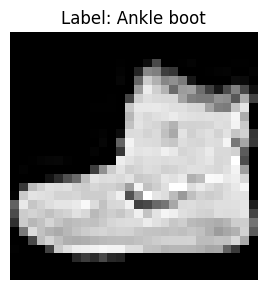

In [ ]:
# 실험용 이미지 1장 준비
image, label = train_dataset[0]
x = image.unsqueeze(0).to(device)   # [1, 1, 28, 28]

print(f"입력 shape : {x.shape}\n")
show_image(train_dataset, idx=0)

입력 shape : torch.Size([1, 1, 28, 28])

------------------------------kernel_size = 3------------------------------

kernel_size = 3                    : shape = (1, 4, 26, 26)


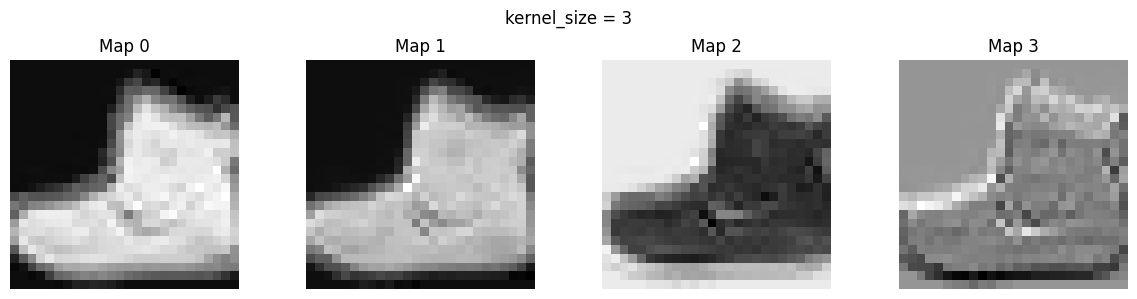

공식으로 계산한 output size : [1, 4, 26, 26]

------------------------------kernel_size = 8------------------------------

kernel_size = 8                    : shape = (1, 4, 21, 21)


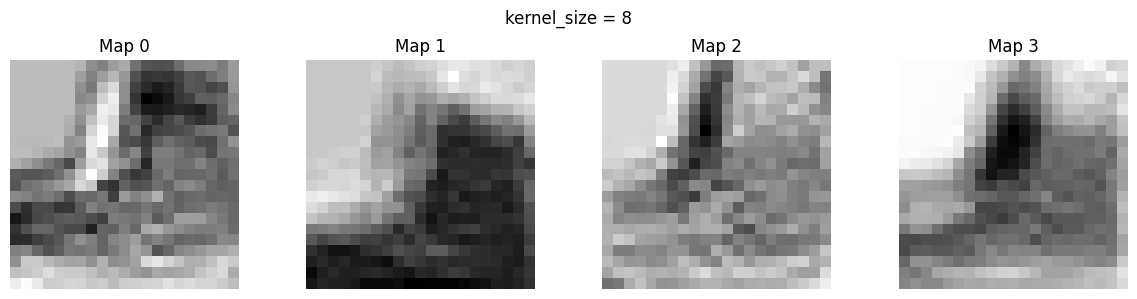

공식으로 계산한 output size : [1, 4, 21, 21]


In [ ]:
########### 실험 1: kernel_size의 영향 ###########
conv_k3 = nn.Conv2d(
    in_channels=1,      # 입력 채널 수: 1
    out_channels=4,     # 출력 채널 수: 4
    kernel_size=3,      # 커널 크기: 3x3
    stride=1,
    padding=0,
).to(device)

conv_k8 = nn.Conv2d(
    in_channels=1,      # 입력 채널 수: 1
    out_channels=4,     # 출력 채널 수: 4
    kernel_size=8,      # 커널 크기: 8x8
    stride=1,
    padding=0,
).to(device)


# 정의한 각 convolution layer에 이미지 한 개를 입력합니다.
with torch.no_grad():
    out_k3 = conv_k3(x)
    out_k8 = conv_k8(x)


# output size 공식
# output = ((input + 2*padding - kernel_size) // stride) + 1

input_h, input_w = x.shape[2], x.shape[3]
padding = 0
stride = 1

out_h_k3 = ((input_h + 2 * padding - 3) // stride) + 1
out_w_k3 = ((input_w + 2 * padding - 3) // stride) + 1

out_h_k8 = ((input_h + 2 * padding - 8) // stride) + 1
out_w_k8 = ((input_w + 2 * padding - 8) // stride) + 1

print(f"입력 shape : {x.shape}\n")

print("------------------------------kernel_size = 3------------------------------\n")
# kernel_size=3 결과
# 작은 커널(k=3)은 더 국소적인 패턴을 반영합니다.
visualize_feature_maps(out_k3, "kernel_size = 3")
print(f"공식으로 계산한 output size : [1, 4, {out_h_k3}, {out_w_k3}]\n")

print("------------------------------kernel_size = 8------------------------------\n")
# kernel_size=8 결과
# 큰 커널(k=8)은 더 넓은 영역의 정보를 한 번에 반영합니다.
visualize_feature_maps(out_k8, "kernel_size = 8")
print(f"공식으로 계산한 output size : [1, 4, {out_h_k8}, {out_w_k8}]")


# kernel_size가 커질수록 출력 feature map의 spatial size가 작아집니다.

입력 shape : torch.Size([1, 1, 28, 28])

------------------------------stride = 1------------------------------

stride = 1                         : shape = (1, 4, 26, 26)


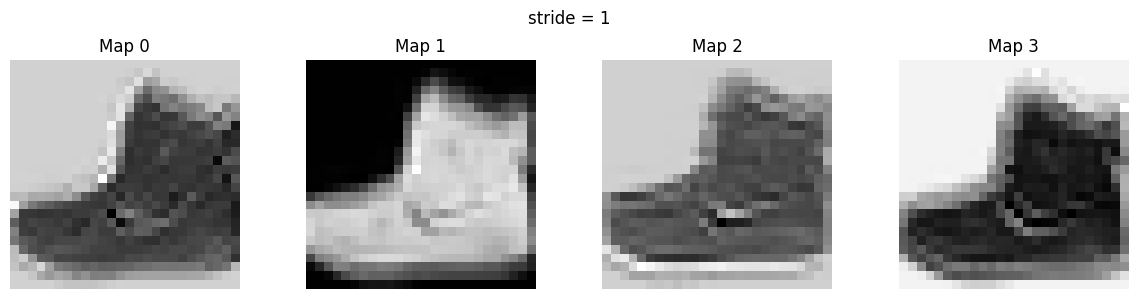

공식으로 계산한 output size (stride=1) : [1, 8, 26, 26]

------------------------------stride = 2------------------------------

stride = 2                         : shape = (1, 4, 13, 13)


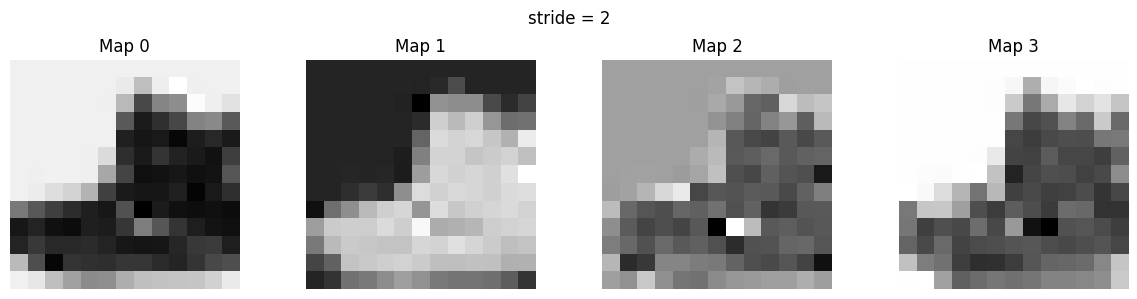

공식 계산 결과 (stride=2) : [1, 8, 13, 13]


In [ ]:
############ 실험 2: stride의 영향 ###########
conv_s1 = nn.Conv2d(
    in_channels=1,      # 입력 채널 수: 1
    out_channels=4,     # 출력 채널 수: 4
    kernel_size=3,      # 커널 크기: 3x3
    stride=1,           # 이동 간격: 1
    padding=0,
).to(device)

conv_s2 = nn.Conv2d(
    in_channels=1,      # 입력 채널 수: 1
    out_channels=4,     # 출력 채널 수: 4
    kernel_size=3,      # 커널 크기: 3x3
    stride=2,           # 이동 간격: 2
    padding=0,
).to(device)


# 정의한 각 convolution layer에 이미지 한 개를 입력합니다.
with torch.no_grad():
    out_s1 = conv_s1(x)
    out_s2 = conv_s2(x)


# output size 공식
# output = ((input + 2 * padding - kernel_size) // stride) + 1

input_h, input_w = x.shape[2], x.shape[3]
kernel_size = 3
padding = 0

out_h_s1 = ((input_h + 2 * padding - kernel_size) // 1) + 1
out_w_s1 = ((input_w + 2 * padding - kernel_size) // 1) + 1

out_h_s2 = ((input_h + 2 * padding - kernel_size) // 2) + 1
out_w_s2 = ((input_w + 2 * padding - kernel_size) // 2) + 1


print(f"입력 shape : {x.shape}\n")

print("------------------------------stride = 1------------------------------\n")
# stride=1 결과
# stride=1은 입력을 더 촘촘하게 반영합니다.
visualize_feature_maps(out_s1, "stride = 1")
print(f"공식으로 계산한 output size (stride=1) : [1, 8, {out_h_s1}, {out_w_s1}]\n")


print("------------------------------stride = 2------------------------------\n")
# stride=2 결과
# stride=2는 입력을 더 성기게 샘플링하여 특징을 추출합니다.
visualize_feature_maps(out_s2, "stride = 2")
print(f"공식 계산 결과 (stride=2) : [1, 8, {out_h_s2}, {out_w_s2}]")

# stride가 커질수록 커널이 이동하는 간격이 넓어지므로 출력 feature map의 spatial size가 더 작아집니다.


입력 shape : torch.Size([1, 1, 28, 28])

------------------------------padding = 0------------------------------

padding = 0                        : shape = (1, 4, 26, 26)


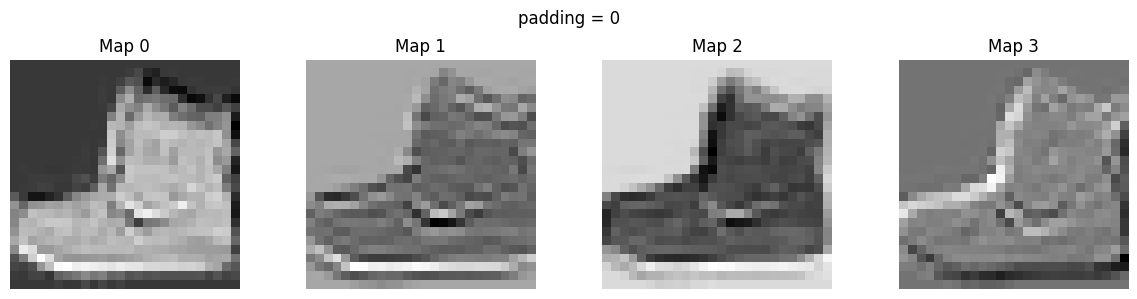

공식으로 계산한 출력 shape : [1, 8, 26, 26]

------------------------------padding = 1------------------------------

padding = 1                        : shape = (1, 4, 28, 28)


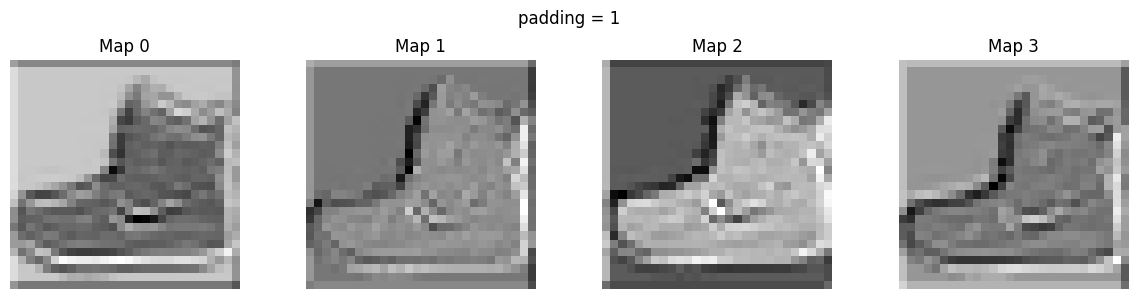

공식으로 계산한 출력 shape : [1, 8, 28, 28]



In [ ]:
############# 실험 3: padding의 영향 ###########
conv_p0 = nn.Conv2d(
    in_channels=1,      # 입력 채널 수: 1
    out_channels=4,     # 출력 채널 수: 4
    kernel_size=3,      # 커널 크기: 3x3
    stride=1,           # 이동 간격: 1
    padding=0,          # 가장자리를 채우지 않으므로 출력 크기가 줄어듦
).to(device)

conv_p1 = nn.Conv2d(
    in_channels=1,      # 입력 채널 수: 1
    out_channels=4,     # 출력 채널 수: 4
    kernel_size=3,      # 커널 크기: 3x3
    stride=1,           # 이동 간격: 1
    padding=1,          # 가장자리를 1칸씩 채워서 출력 크기를 유지하기 쉬움
).to(device)


# 정의한 각 convolution layer에 이미지 한 개를 입력합니다.
with torch.no_grad():
    out_p0 = conv_p0(x)
    out_p1 = conv_p1(x)


# output size 공식
# output = ((input + 2 * padding - kernel_size) // stride) + 1

input_h, input_w = x.shape[2], x.shape[3]
kernel_size = 3
stride = 1

out_h_p0 = ((input_h + 2 * 0 - kernel_size) // stride) + 1
out_w_p0 = ((input_w + 2 * 0 - kernel_size) // stride) + 1

out_h_p1 = ((input_h + 2 * 1 - kernel_size) // stride) + 1
out_w_p1 = ((input_w + 2 * 1 - kernel_size) // stride) + 1


print(f"입력 shape : {x.shape}\n")
print("------------------------------padding = 0------------------------------\n")
# padding=0 결과
# padding=0은 가장자리를 채우지 않기 때문에 출력 feature map의 높이와 너비가 줄어듭니다.
visualize_feature_maps(out_p0, "padding = 0")
print(f"공식으로 계산한 출력 shape : [1, 8, {out_h_p0}, {out_w_p0}]\n")


print("------------------------------padding = 1------------------------------\n")
# padding=1 결과
# padding=1은 3x3 convolution을 적용해도 높이와 너비가 유지되는 경향이 있습니다.
visualize_feature_maps(out_p1, "padding = 1")
print(f"공식으로 계산한 출력 shape : [1, 8, {out_h_p1}, {out_w_p1}]\n")


# 두 결과를 비교하면서 padding=0 에서 "출력 크기가 실제로 줄었는지"를 눈으로 확인해봅니다.

## 1-2. Warm-up용 아주 간단한 CNN 모델
- 입력 이미지

   [B, 1, 28, 28]

      ↓ Conv2d

   [B, 8, 28, 28]

      ↓ ReLU

   [B, 8, 28, 28]

      ↓ MaxPool2d

   [B, 8, 14, 14]

      ↓ Flatten

   [B, 1568]

      ↓ Linear
      
   [B, 10]

- Conv2d는 feature map을 만든다.

- ReLU는 비선형성을 추가한다.

- MaxPool2d는 공간 크기를 줄여 중요한 특징을 압축한다.

- Linear는 최종적으로 10개 클래스 점수(logit)를 만든다.

### 1-2-1. Warm-up CNN의 feature map 시각화
원본 이미지와 feature map을 함께 보면서, convolution과 max pooling이 어떤 변화를 만드는지 관찰한다.

지금은 아직 **학습 전** 상태이다.

즉, 필터가 랜덤 초기화 상태이므로 feature map이 아주 의미 있게 보이지 않을 수 있다.

그럼에도 불구하고 "채널별로 서로 다른 반응이 나타난다"는 점, "pooling 후 공간 크기가 줄어든다"는 점을 관찰하는 데 의미가 있다.

모델 생성을 생성하였습니다. 모델의 구조를 직접 확인해볼 수 있습니다.
WarmupCNN(
  (conv): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)


모델의 각 단계에서 feature map이 어떻게 변하는지 확인해볼 수 있습니다.
Input                 : (1, 1, 28, 28)
After Conv            : (1, 8, 28, 28)
After MaxPool         : (1, 8, 14, 14)
Output logits         : (1, 10)

각 단계에서 feature map의 8개 채널을 모두 시각화하여, 이미지가 어떻게 변하는지 눈으로 확인해볼 수 있습니다.
[input 이미지]


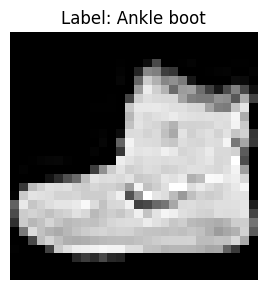

[convolution 레이어 통과 후 특징 맵]
WarmupCNN - Feature maps after Conv: shape = (1, 8, 28, 28)


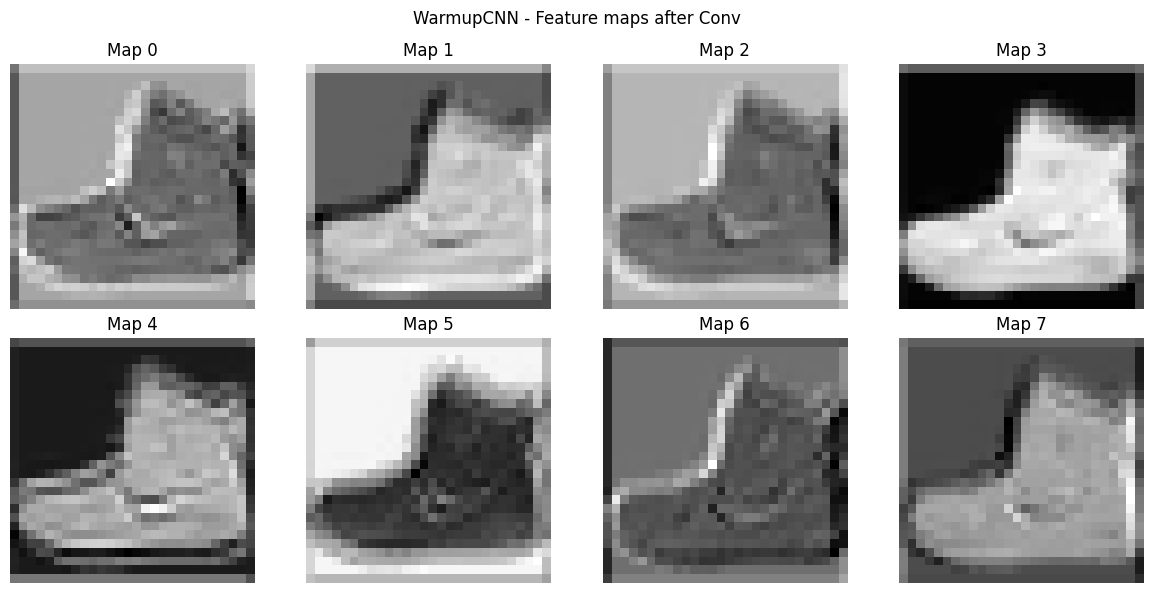

[maxpool 레이어 통과 후 특징 맵]
WarmupCNN - Feature maps after MaxPool: shape = (1, 8, 14, 14)


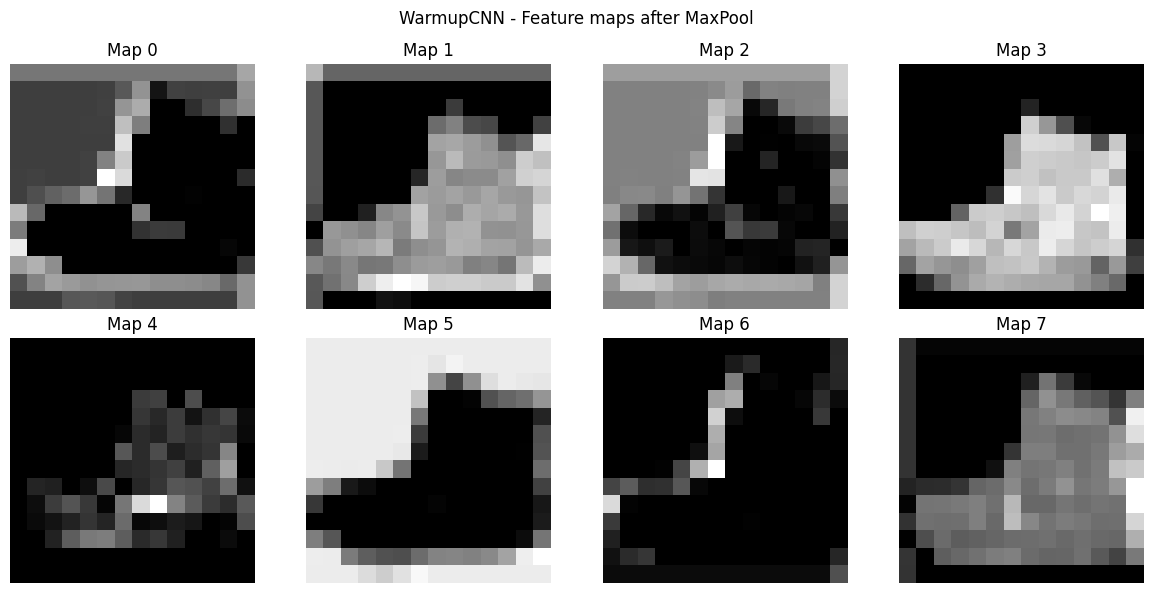

In [ ]:
# WarmupCNN 모델 정의
class WarmupCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()

        # ----------------------------------------------------
        # Convolution layer
        # ----------------------------------------------------
        # in_channels=1  : 흑백 이미지이므로 입력 채널은 1개
        # out_channels=8 : 서로 다른 필터 8개를 적용하여 8장의 feature map을 만든다
        # kernel_size=3  : 3x3 필터 사용
        # stride=1       : 한 칸씩 이동
        # padding=1      : 가장자리에 1칸 padding을 주어 출력 크기가 28x28로 유지되도록 함
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # ReLU는 음수 값을 0으로 보내는 활성화 함수
        # CNN에서는 거의 기본처럼 자주 사용된다.
        self.relu = nn.ReLU()

        # MaxPool2d는 2x2 영역에서 최댓값 하나만 남긴다.
        # kernel_size=2, stride=2 이므로 높이와 너비가 절반으로 줄어든다. (28x28 -> 14x14)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten은 [B, C, H, W] 형태를 [B, C*H*W] 형태로 바꾼다.
        # Fully Connected(Linear) 레이어에 넣기 위해 필요하다.
        self.flatten = nn.Flatten()

        # flatten 이후 shape는 [B, C*H*W]
        # 최종적으로 10개 클래스 점수를 출력한다.
        self.fc = nn.Linear(8 * 14 * 14, num_classes)

    # ----------------------------------------------------
    # 이 함수는 일반적인 forward와 거의 같지만, 중간 결과(feature map)도 함께 반환한다.
    # 실습에서는 "각 단계에서 이미지가 어떻게 바뀌는지" 직접 눈으로 보는 것이 중요하므로 따로 만든다.
    # 해당 빈칸은 이해를 돕기 위해 TA가 정답을 보여줄 예정입니다. 정답을 보고 직접 작성해보세요.
    # ----------------------------------------------------
    def forward_with_feature_maps(self, x: torch.Tensor):
        conv_out = self.conv(x)      ###### [실습] self.conv에 입력 x를 입력시켜 convolution을 수행하세요. ######
        relu_out = self.relu(conv_out)      ###### [실습] self.relu에 conv_out를 입력하세요. ######
        pool_out = self.pool(relu_out)      ###### [실습] self.pool에 relu_out를 입력하여 max pooling을 수행하세요. ######
        flat_out = self.flatten(pool_out)      ###### [실습] self.flatten에 pool_out을 입력하여 1차원 벡터로 펼치세요. ######
        logits = self.fc(flat_out)        ###### [실습] self.fc 선형층에 flat_out을 입력시켜 클래스 점수(logit)를 계산하세요. ######

        return logits, {
            "conv": conv_out,
            "relu": relu_out,
            "pool": pool_out,
        }

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_with_feature_maps(x)[0]  # feature map은 필요 없으므로 logits만 반환
        return x

# 모델 생성
# .to(device)를 통해 모델 내부의 파라미터를 CPU 또는 GPU로 보낸다.
# 데이터와 모델은 반드시 같은 device 위에 있어야 계산이 가능하다.
print("모델 생성을 생성하였습니다. 모델의 구조를 직접 확인해볼 수 있습니다.")
warmup_model = WarmupCNN().to(device)
print(warmup_model)
print("\n")

# 각 단계의 feature map shape 확인
# 첫 번째 학습 샘플 하나를 가져온다.
image, label = train_dataset[0]
# dataset에서 꺼낸 image의 shape는 [1, 28, 28]
# 하지만 모델은 [B, C, H, W] 형태를 기대하므로 unsqueeze(0)을 해서 batch 차원을 추가한다.
# 즉, [1, 28, 28] -> [1, 1, 28, 28]
# 모델과 같은 device로 이동한다.
x = image.unsqueeze(0).to(device)

# 학습(gradient 계산)이 목적이 아니므로 no_grad()를 사용한다.
# 이렇게 하면 메모리를 덜 쓰고 조금 더 빠르게 계산할 수 있다.
with torch.no_grad():
    logits, warmup_features = warmup_model.forward_with_feature_maps(x)

# 각 단계에서 shape가 어떻게 변하는지 확인한다.
# CNN을 이해할 때 가장 중요한 습관 중 하나는 "각 레이어 뒤 shape를 추적하는 것"이다.
print("모델의 각 단계에서 feature map이 어떻게 변하는지 확인해볼 수 있습니다.")
print_shape("Input", x)
print_shape("After Conv", warmup_features["conv"])
print_shape("After MaxPool", warmup_features["pool"])
print_shape("Output logits", logits)

# 각 단계에서 feature map의 일부 채널을 시각화
print("\n각 단계에서 feature map의 8개 채널을 모두 시각화하여, 이미지가 어떻게 변하는지 눈으로 확인해볼 수 있습니다.")
print("[input 이미지]")
show_image(train_dataset, idx=0)

print("[convolution 레이어 통과 후 특징 맵]")
visualize_feature_maps(
    warmup_features["conv"],
    "WarmupCNN - Feature maps after Conv"
)

print("[maxpool 레이어 통과 후 특징 맵]")
visualize_feature_maps(
    warmup_features["pool"],
    "WarmupCNN - Feature maps after MaxPool"
)

## 1-3. 본 실습용 VGG-style Simple CNN 정의

구조는 VGG 스타일을 단순화한 형태로, "Conv -> ReLU -> Conv -> ReLU -> Pool" 블록을 두 번 사용한다.

**전체 흐름:**

[B, 1, 28, 28]

    -> conv1 -> relu1 -> conv2 -> relu2 -> pool1

[B, 32, 14, 14]

    -> conv3 -> relu3 -> conv4 -> relu4 -> pool2

[B, 64, 7, 7]

    -> flatten -> fc1 -> relu -> dropout -> fc2

[B, 10]

**feature map shape 수식**
- $\text{output\_size} = \frac{\text{input\_size} + 2 \times \text{padding} - \text{kernel\_size}}{\text{stride}}+1$

**실습 확인**
- 해당 셀을 실행시키면 모델을 정의 및 생성할 수 있습니다.
- 에러 없이 모델이 생성되도록 해야합니다.

In [ ]:
# 모델 정의
class SimpleVGG(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()

        # ----------------------------------------------------
        # Block 1
        # ----------------------------------------------------
        # 입력: [B, 1, 28, 28]
        # conv1 출력: [B, 32, 28, 28] - 1채널 입력을 32채널 feature map으로 확장
        # input channel 1을 받고 output channel 32로 출력합니다.
        # ((28 + 2 * padding - 3) / 1) + 1 = 28
        ###### [실습] 아래 빈칸을 채워서 SimpleVGG 모델의 convolution 부분을 완성하세요. ######
        self.conv1 = nn.Conv2d(in_channels=1,out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()

        # conv2 출력: [B, 32, 28, 28]
        # convolution은 torch.nn.Conv2d로 구현하며, torch.nn을 nn으로 import 했으므로 nn.Conv2d로 작성합니다.
        # conv1과 relu1을 통과한 feature map
        # input channel 32를 받고 output channel 32로 출력합니다.
        # 이외의 feature map (image size)는 그대로 고정시킵니다.
        # ((28 + 2 * 1 - 3) / 1) + 1 = 28
        ###### [실습] 아래 빈칸을 채워서 SimpleVGG 모델의 convolution 부분을 완성하세요. ######
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()

        # pool1 출력: [B, 32, 14, 14]
        # nn.MaxPool2d도 nn.Conv2d와 같은 수식으로 output shape이 결정됩니다.
        # 여기서 nn.MaxPool2d의 목표는 feature map의 높이/너비를 절반으로 줄여
        # 계산량을 줄이고 중요한 특징을 압축하는 것입니다.
        # ((28 + 2 * 0 - kernel_size) / 2) + 1 = 14
        ###### [실습] 아래 빈칸을 채워서 SimpleVGG 모델의 pooling 부분을 완성하세요. ######
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # ----------------------------------------------------
        # Block 2
        # ----------------------------------------------------
        # conv3 출력: [B, 64, 14, 14] - 채널 수를 늘려 더 다양한 특징을 담는다
        # convolution은 torch.nn.Conv2d로 구현하며, torch.nn을 nn으로 import 했으므로 nn.Conv2d로 작성합니다.
        # input channel 32을 받고 output channel 64로 출력합니다.
        # 이외의 feature map (image size)는 그대로 고정시킵니다.
        # ((14 + 2 * 1 - kernel_size) / 1) + 1 = 14
        ###### [실습] 아래 빈칸을 채워서 SimpleVGG 모델의 convolution 부분을 완성하세요. ######
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()

        # conv4 출력: [B, 64, 14, 14]
        # convolution은 torch.nn.Conv2d로 구현하며, torch.nn을 nn으로 import 했으므로 nn.Conv2d로 작성합니다.
        # input channel 64을 받고 output channel 64로 출력합니다.
        # 이외의 feature map (image size)는 그대로 고정시킵니다.
        # ((14 + 2 * 1 - 3) / stride) + 1 = 14
        ###### [실습] 아래 빈칸을 채워서 SimpleVGG 모델의 convolution 부분을 완성하세요. ######
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu4 = nn.ReLU()

        # pool2 출력: [B, 64, 7, 7]
        # MaxPooling은 torch.nn.MaxPool2d로 구현하며, torch.nn을 nn으로 import 했으므로 nn.MaxPool2d로 작성합니다.
        # nn.MaxPool2d도 nn.Conv2d와 같은 수식으로 output shape이 결정됩니다.
        # 여기서 nn.MaxPool2d의 목표는 feature map의 높이/너비를 절반으로 줄여
        # 계산량을 줄이고 중요한 특징을 압축하는 것입니다.
        # ((14 + 2 * 0 - kernel_size) / 2) + 1 = 7
        ###### [실습] 아래 빈칸을 채워서 SimpleVGG 모델의 pooling 부분을 완성하세요. ######
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # ----------------------------------------------------
        # Classifier 부분
        # ----------------------------------------------------
        # convolution/pooling으로 얻은 feature map을 최종 클래스 점수로 바꾸는 부분
        # Flatten은 [B, C, H, W] 형태를 [B, C*H*W] 형태로 바꾼다.
        # 여기서는 self.pool2에서 나온 [B, 64, 7, 7]을 [B, 3136]로 바꾼다. (3136 = 64 * 7 * 7)
        self.flatten = nn.Flatten()

        # self.flatten에서 받은 표현(특징)을 128차원의 은닉 표현으로 변환
        # input으로 self.pool2에서 나온 feature map을 self.flatten이 펼친 것이 들어옵니다.
        ###### [실습] 아래 빈칸을 채워서 SimpleVGG 모델의 classifier 중 fully connected 부분을 완성하세요. ######
        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        # fully connected 층 사이에도 ReLU 사용
        self.relu_fc = nn.ReLU()

        # dropout은 일부 뉴런을 학습 시 무작위로 꺼서 과적합(overfitting)을 줄이는 데 도움을 준다.
        self.dropout = nn.Dropout(0.3)

        # 마지막으로 데이터의 label 개수로 표현을 줄인다.
        self.fc2 = nn.Linear(128, num_classes)

    def forward_with_feature_maps(self, x: torch.Tensor):
        ###### [실습] 아래 빈칸을 채워서 forward_with_feature_maps 함수를 완성하세요. ######
        # ----------------------------------------------------
        # Block 1
        # ----------------------------------------------------
        # -> conv1 -> relu1 -> conv2 -> relu2 -> pool1
        x = self.conv1(x)            # 첫 번째 convolution
        fmap1 = self.relu1(x)        # 첫 번째 활성화 함수
        x = self.conv2(fmap1)        # 두 번째 convolution
        fmap2 = self.relu2(x)        # 두 번째 활성화 함수
        pooled1 = self.pool1(fmap2)  # 첫 번째 pooling

        # ----------------------------------------------------
        # Block 2
        # ----------------------------------------------------
        # -> conv3 -> relu3 -> conv4 -> relu4 -> pool2
        x = self.conv3(pooled1)         ###### [실습] 세 번째 convolution ######

        fmap3 = self.relu3(x)           ###### [실습] 세 번째 활성화 함수 ######

        x = self.conv4(fmap3)           ###### [실습] 네 번째 convolution ######

        fmap4 = self.relu4(x)           ###### [실습] 네 번째 활성화 함수 ######

        pooled2 = self.pool2(fmap4)     ###### [실습] 두 번째 pooling ######

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------
        # -> flatten -> fc1 -> relu -> dropout -> fc2
        x = self.flatten(pooled2)  # 4차원 텐서를 2차원으로 펼친다.
        x = self.fc1(x)              ###### [실습] fully connected layer로 특징을 128차원으로 줄인다. ######

        x = self.relu_fc(x)        # 활성화 함수 적용
        x = self.dropout(x)        # dropout 적용 (학습 중에만 의미 있음)
        logits = self.fc2(x)       # 최종 클래스 점수(logit) 출력

        return logits, {
            "conv1": fmap1,
            "conv2": fmap2,
            "pool1": pooled1,
            "conv3": fmap3,
            "conv4": fmap4,
            "pool2": pooled2,
        }

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # _extract_features는 (logits, feature_maps) 튜플을 반환하므로 logits만 가져온다.
        x = self.forward_with_feature_maps(x)[0]
        return x

# 모델 생성
model = SimpleVGG().to(device)
print("모델을 생성하였습니다. 제대로 모델을 정의했다면 모델의 구조를 직접 확인해볼 수 있습니다.")
print(model)

# train_loader에서 첫 번째 batch를 꺼낸다.
example_images, _ = next(iter(train_loader))
# 실습 화면을 깔끔하게 하기 위해 앞의 4장만 사용
example_images = example_images[:4].to(device)

# gradient 계산 없이 중간 결과만 확인
with torch.no_grad():
    logits, features = model.forward_with_feature_maps(example_images)

print("\n각 단계의 출력 형태 확인할 수 있습니다.")
print_shape("Input", example_images)
print_shape("After conv1", features["conv1"])
print_shape("After conv2", features["conv2"])
print_shape("After pool1", features["pool1"])
print_shape("After conv3", features["conv3"])
print_shape("After conv4", features["conv4"])
print_shape("After pool2", features["pool2"])
print_shape("Output logits", logits)

모델을 생성하였습니다. 제대로 모델을 정의했다면 모델의 구조를 직접 확인해볼 수 있습니다.
SimpleVGG(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu_fc): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

각 단계의 출력 형태 확인할 수 있습니다.
Input                 : (4, 1, 28, 28)
After conv1           : (4, 32, 28, 28)
After conv2           : (4, 32, 28, 28)
After po

# 2. 모델 학습 및 학습 전/후 feature map 시각화

**학습(train) / 평가(eval) 함수 정의**

1) loss function

   - 모델의 예측이 얼마나 틀렸는지 숫자로 측정
   - 이미지 분류 문제이므로 CrossEntropyLoss를 사용

2) optimizer

   - loss를 줄이는 방향으로 weight를 업데이트

3) train / eval loop

   - 데이터셋 전체를 돌면서 loss, accuracy를 계산

**모델 학습 진행**

- epoch마다 다음 과정을 반복한다.

    - train_loader로 모델 학습

    - test_loader로 현재 성능 평가

    - loss와 accuracy 출력

- 학습이 끝난 뒤에는 같은 이미지의 feature map을 시각화하여 학습 전과 비교해본다.

- 추가로 훈련 시간이 너무 오래걸릴 경우, **epochs**을 줄여주세요.

**학습 전/후 feature map 시각화**

- 학습 전 feature map은 랜덤 초기화의 영향으로 반응이 비교적 산만하거나 해석이 어려울 수 있습니다.

- 학습 후에는 일부 채널의 반응 패턴이 달라지지만, 그 변화가 항상 사람 눈에 명확한 형태로 보이지는 않습니다.

- 중요한 점은 “사람이 보기 좋은 이미지가 되었는가”가 아니라, **모델이 특정 위치나 패턴에 더 선택적으로 반응하도록 변했는가**입니다.

[학습 전 feature map]


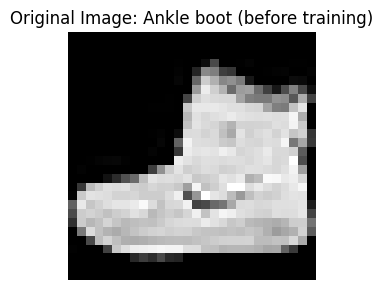

※ 현재 시각화는 'before training' feature map입니다.
  학습 후에는 일부 채널이 더 뚜렷한 패턴에 반응하는지 관찰해보세요.
SimpleVGG - pool1 (before training): shape = (1, 32, 14, 14)


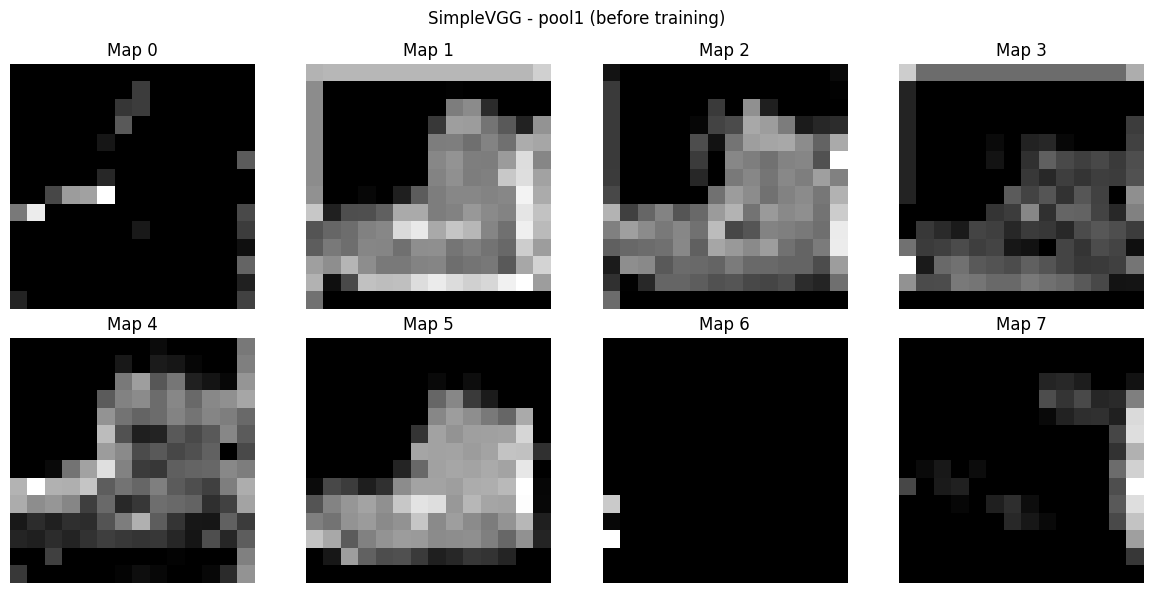

SimpleVGG - pool2 (before training): shape = (1, 64, 7, 7)


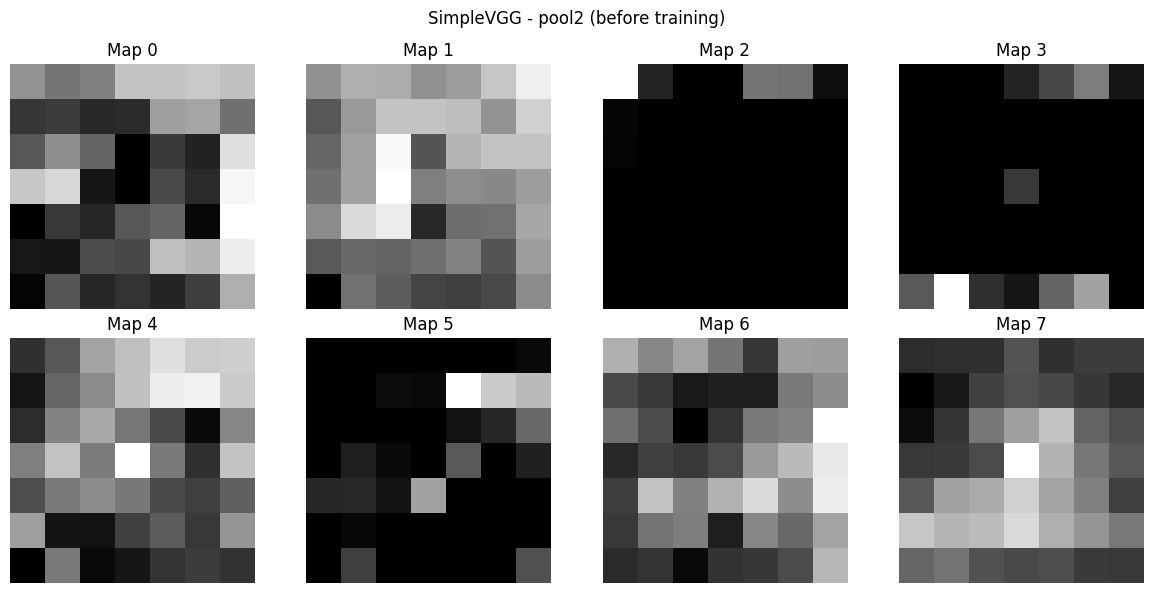


[Training]


 10%|█         | 1/10 [00:21<03:17, 21.94s/it]

Epoch [1/10] | Train Loss: 0.4802, Train Acc: 0.8267 | Test Loss: 0.2999, Test Acc: 0.8888


 20%|██        | 2/10 [00:42<02:47, 21.00s/it]

Epoch [2/10] | Train Loss: 0.2921, Train Acc: 0.8952 | Test Loss: 0.2475, Test Acc: 0.9080


...

Epoch [8/10] | Train Loss: 0.1361, Train Acc: 0.9500 | Test Loss: 0.2358, Test Acc: 0.9206


 90%|█████████ | 9/10 [03:08<00:20, 20.86s/it]

Epoch [9/10] | Train Loss: 0.1209, Train Acc: 0.9549 | Test Loss: 0.2343, Test Acc: 0.9243


100%|██████████| 10/10 [03:28<00:00, 20.87s/it]

Epoch [10/10] | Train Loss: 0.1090, Train Acc: 0.9588 | Test Loss: 0.2506, Test Acc: 0.9235

[학습 후 feature map]
학습 전과 같은 이미지를 다시 보면서, 일부 feature map이 더 구조적인 패턴을 보이는지 관찰해보세요.


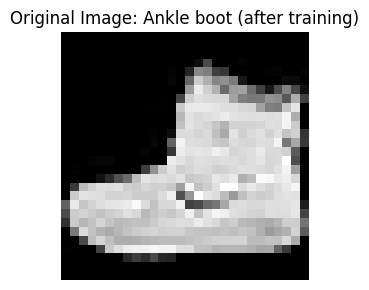

※ 현재 시각화는 'after training' feature map입니다.
  학습 후에는 일부 채널이 더 뚜렷한 패턴에 반응하는지 관찰해보세요.
SimpleVGG - pool1 (after training) : shape = (1, 32, 14, 14)


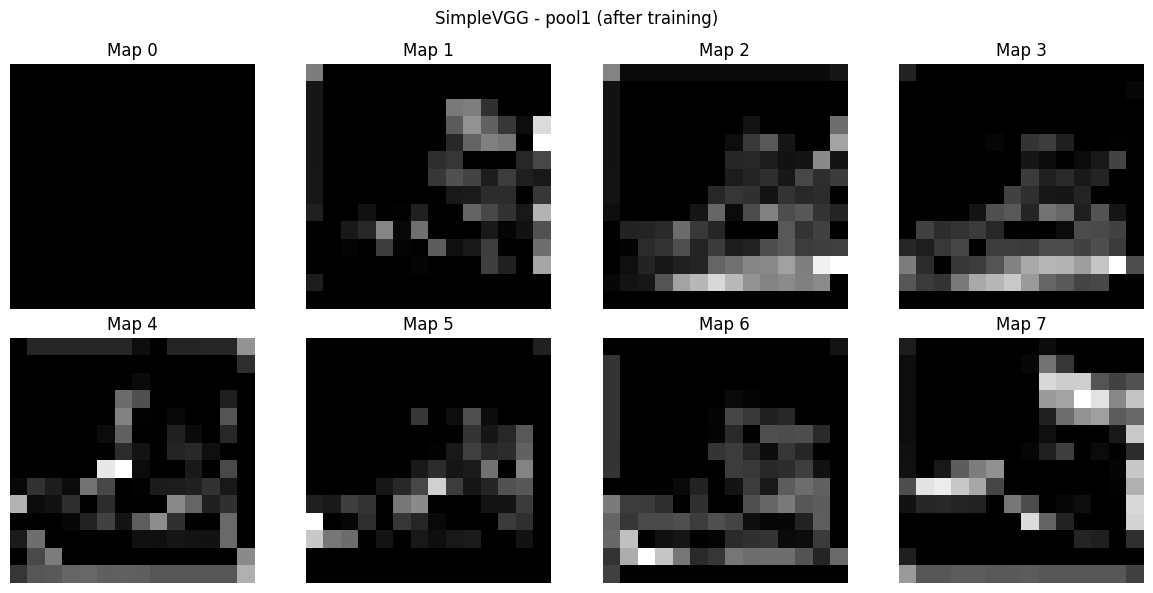

SimpleVGG - pool2 (after training) : shape = (1, 64, 7, 7)


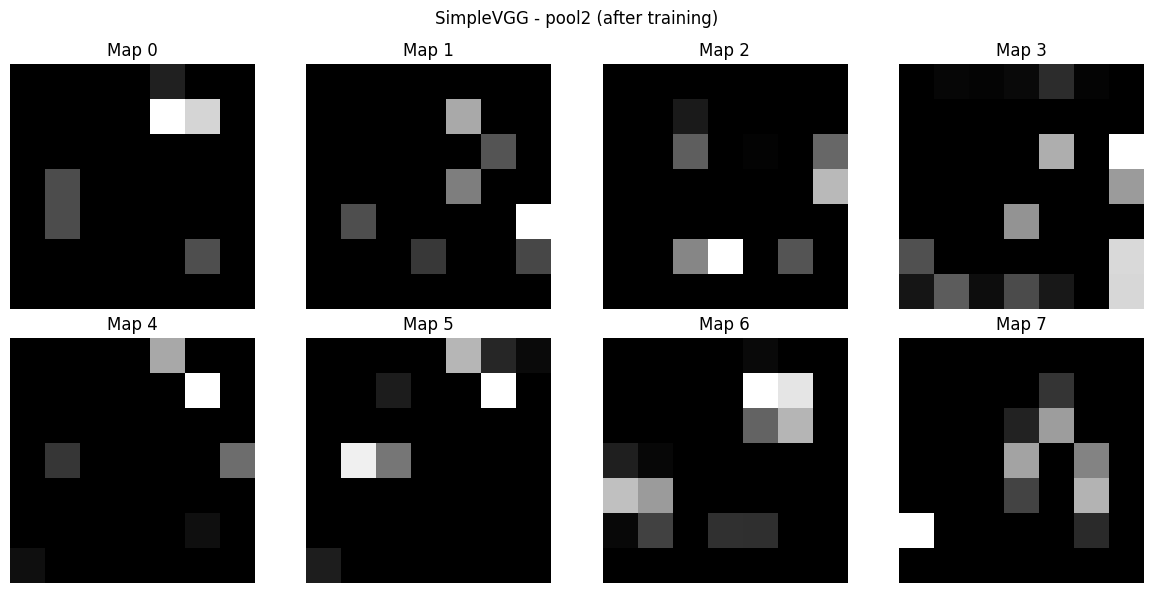

In [ ]:
# 훈련 시간이 너무 오래걸린다면 epochs 수를 줄여주세요.
epochs = 10

criterion = nn.CrossEntropyLoss() # 분류 문제용 손실 함수
optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Adam optimizer

# --------------------------------------------------------
# 한 epoch 동안 모델을 학습시키는 함수
# --------------------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer):     # 한 epoch 동안 모델을 학습시키는 함수
    # model.train()은 모델을 "학습 모드"로 전환한다.
    # dropout 같은 레이어는 학습 모드와 평가 모드에서 다르게 동작한다.
    model.train()

    # epoch 전체 loss와 accuracy를 계산하기 위한 누적 변수
    running_loss = 0.0
    correct = 0
    total = 0

    # loader는 batch 단위로 (images, labels)를 반환한다.
    for images, labels in loader:
        # 데이터도 모델과 같은 device로 보내야 한다.
        images, labels = images.to(device), labels.to(device)

        # 이전 step에서 계산된 gradient를 초기화한다.
        # PyTorch는 gradient를 기본적으로 누적(accumulate)하기 때문에
        # 매 step마다 zero_grad()를 호출해야 한다.
        optimizer.zero_grad()

        # forward: 모델 예측
        outputs = model(images)

        # 예측값(outputs)과 정답(labels)을 비교하여 loss 계산
        loss = criterion(outputs, labels)

        # backward: loss를 기준으로 gradient 계산
        loss.backward()

        # optimizer step: gradient를 이용해 파라미터 업데이트
        optimizer.step()

        # batch loss를 샘플 수 기준으로 누적
        running_loss += loss.item() * images.size(0)

        # 가장 큰 점수를 가진 클래스를 예측값으로 사용
        preds = outputs.argmax(dim=1)

        # 맞춘 개수 누적
        correct += (preds == labels).sum().item()

        # 전체 샘플 수 누적
        total += labels.size(0)

    return running_loss / total, correct / total

# --------------------------------------------------------
# 테스트/검증 데이터셋에서 성능을 평가하는 함수
# --------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion):      # 테스트 데이터셋에서 성능을 평가하는 함수
    # model.eval()은 모델을 "평가 모드"로 전환한다.
    # dropout은 평가 시 꺼지고, batchnorm도 추론 방식으로 동작한다.
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 평가 시에도 forward는 동일하게 수행
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

# 학습 전 상태에서 먼저 feature map을 한 번 본다.
# show_vgg_feature_maps는 feature map을 시각화할 수 있는 함수이다.
print("[학습 전 feature map]")
show_vgg_feature_maps(model, train_dataset, idx=0, stage="before training")

print("\n[Training]")
for epoch in tqdm(range(epochs)):
    # 한 epoch 학습
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    # 현재 epoch가 끝난 뒤 테스트 성능 평가
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    tqdm.write(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
    )

print("\n[학습 후 feature map]")
print("학습 전과 같은 이미지를 다시 보면서, 일부 feature map이 더 구조적인 패턴을 보이는지 관찰해보세요.")
show_vgg_feature_maps(model, train_dataset, idx=0, stage="after training")

## 2-1. 추론(inference) 예시와 오분류 예시 확인

학습이 끝났다면 실제로 이미지 한 장을 넣어 예측 결과를 확인할 수 있다.

여기서는 두 가지를 보여준다.

1) predict_one_image

   - 특정 이미지 1장에 대해 "이 이미지는 몇 % 확률로 어떤 클래스입니다"를 출력

2) show_one_misclassified_example

   - 모델이 틀린 예시 하나를 찾아 보여줌
   
   - 모델이 항상 완벽한 것은 아니라는 점, 어떤 클래스끼리 헷갈릴 수 있는지를 보여주는 데 유용하다.

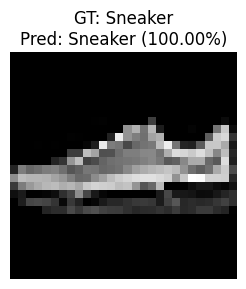

정답 : Sneaker
예측 : 100.00% 확률로 Sneaker

[모델이 헷갈린 예시 하나 보기]


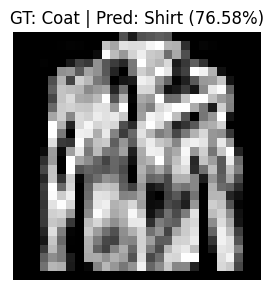

[오분류 예시] idx=17
정답 : Coat
예측 : 76.58% 확률로 Shirt


In [ ]:
@torch.no_grad()
def predict_one_image(model: nn.Module, dataset, idx: int = 0):
    # 평가 모드 전환
    model.eval()

    # 특정 샘플 1개를 가져온다.
    image, label = dataset[idx]

    # 배치 차원 추가 후 device로 이동
    x = image.unsqueeze(0).to(device)

    # 모델 예측 수행
    logits = model(x)

    # softmax를 적용하면 각 클래스에 대한 "확률처럼 해석 가능한 값"을 얻을 수 있다.
    # (정확히는 정규화된 점수)
    probs = torch.softmax(logits, dim=1)

    # 가장 높은 확률을 가진 클래스 index
    pred_idx = probs.argmax(dim=1).item()

    # 그 클래스의 확률 값
    pred_prob = probs[0, pred_idx].item()

    # 원본 이미지를 보여주면서 정답과 예측을 함께 표시
    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(0), cmap="gray")
    plt.title(
        f"GT: {classes[label]}\n"
        f"Pred: {classes[pred_idx]} ({pred_prob * 100:.2f}%)"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"정답 : {classes[label]}")
    print(f"예측 : {pred_prob * 100:.2f}% 확률로 {classes[pred_idx]}")

@torch.no_grad()
def show_one_misclassified_example(model: nn.Module, dataset):
    # 평가 모드 전환
    model.eval()

    # 데이터셋 전체를 앞에서부터 순회하면서
    # 첫 번째 오분류 예시를 찾는다.
    for idx in range(len(dataset)):
        image, label = dataset[idx]
        x = image.unsqueeze(0).to(device)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred_idx = probs.argmax(dim=1).item()

        # 예측이 정답과 다르면 오분류 사례
        if pred_idx != label:
            pred_prob = probs[0, pred_idx].item()

            plt.figure(figsize=(3, 3))
            plt.imshow(image.squeeze(0), cmap="gray")
            plt.title(
                f"GT: {classes[label]} | "
                f"Pred: {classes[pred_idx]} ({pred_prob * 100:.2f}%)"
            )
            plt.axis("off")
            plt.tight_layout()
            plt.show()

            print(f"[오분류 예시] idx={idx}")
            print(f"정답 : {classes[label]}")
            print(f"예측 : {pred_prob * 100:.2f}% 확률로 {classes[pred_idx]}")
            return

    # 만약 모든 샘플을 맞췄다면 아래 문장이 출력된다.
    print("오분류 예시를 찾지 못했습니다.")


# 테스트셋 첫 번째 이미지에 대해 예측
predict_one_image(model, test_dataset, idx=9)   # idx 값을 변경하면 다른 결과를 볼 수 있음

print("\n[모델이 헷갈린 예시 하나 보기]")
show_one_misclassified_example(model, test_dataset)